<a href="https://colab.research.google.com/github/Carmen10-171/03MIAR_Algoritmos-de-Optimizacion/blob/main/Ponencia_Parte_4_Deep_Learning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Deep Learning

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras


In [2]:
# Cargamos el dataset Fashion MNIST que viene incluido en Keras.
# Este conjunto de datos contiene 70,000 imágenes en escala de grises (28x28 píxeles)
# divididas en 60,000 para entrenamiento y 10,000 para pruebas.
# Cada imagen representa una prenda de ropa clasificada en una de 10 categorías.

fashion_mnist = keras.datasets.fashion_mnist  # Alias para facilitar el acceso

# Cargamos los datos y los dividimos en dos partes:
# - X_train: imágenes de entrenamiento (60,000 ejemplos)
# - y_train: etiquetas correspondientes a esas imágenes
# - X_test: imágenes de prueba (10,000 ejemplos)
# - y_test: etiquetas correspondientes a las imágenes de prueba
(X_train, y_train), (X_test, y_test) = fashion_mnist.load_data()

# En este punto:
# - X_train y X_test son tensores con forma (num_ejemplos, 28, 28)
#   es decir, imágenes de 28x28 píxeles.
# - y_train y y_test son vectores de enteros (de 0 a 9) representando las clases.



29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


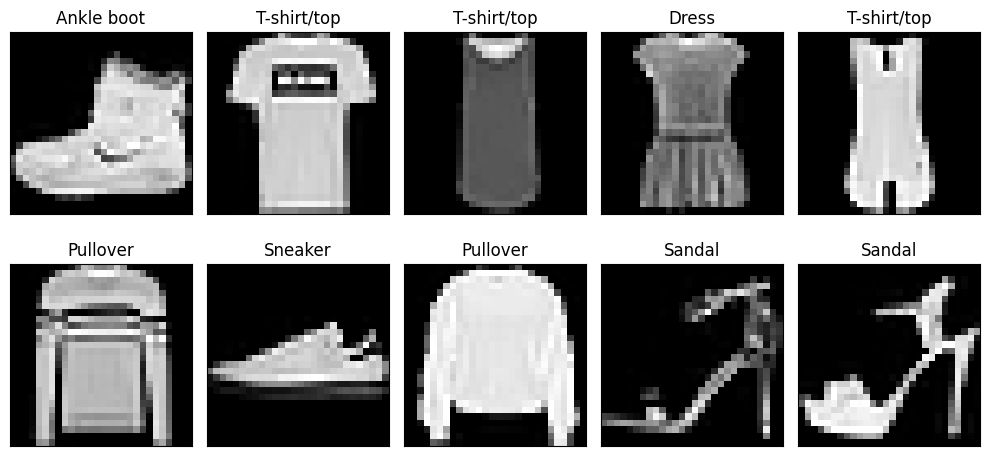

In [3]:
# Definimos una lista con los nombres de las clases del dataset Fashion MNIST.
# Cada número de etiqueta (0 a 9) representa una categoría de ropa.
# Esta lista permite mostrar los nombres reales de las clases en lugar de solo los números.

class_names = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
               'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']

# Creamos una nueva figura de Matplotlib con un tamaño de 10 de ancho por 5 de alto (pulgadas).
# Esto nos permite visualizar múltiples imágenes en una sola fila de subplots.
plt.figure(figsize=(10,5))

# Recorremos los primeros 10 elementos del conjunto de entrenamiento para visualizarlos.
for i in range(10):
    # Creamos un subplot de 2 filas y 5 columnas. Mostramos el subplot número i+1.
    plt.subplot(2, 5, i+1)

    # Eliminamos los valores numéricos de los ejes para que la visualización sea más limpia.
    plt.xticks([])  # Quita los ticks del eje X
    plt.yticks([])  # Quita los ticks del eje Y

    # Mostramos la imagen en escala de grises ('gray') usando la matriz de píxeles correspondiente
    plt.imshow(X_train[i], cmap='gray')

    # Colocamos como título el nombre de la clase usando la etiqueta correspondiente (y_train[i])
    plt.title(class_names[y_train[i]])

# Ajustamos automáticamente los subplots para que no se solapen
plt.tight_layout()

# Mostramos por pantalla todas las imágenes seleccionadas con sus nombres de clase
plt.show()


In [4]:
# Primero normalizamos los datos.
# Los valores de píxeles van de 0 a 255.
# Al dividir entre 255, los llevamos al rango 0–1.
X_train = X_train / 255.0
X_test = X_test / 255.0

# Empezamos a construir el modelo. Será una red secuencial.
# Las capas se añaden una detrás de otra, en orden.
model = keras.Sequential([

    # La primera capa aplana la imagen.
    # Convierte la matriz 28x28 en un vector de 784 elementos.
    keras.layers.Flatten(input_shape=(28, 28)),

    # Luego viene una capa densa con 128 neuronas.
    # Usamos activación ReLU para introducir no linealidad.
    # También añadimos regularización L2 para evitar sobreajuste.
    keras.layers.Dense(128, activation='relu',
                       kernel_regularizer=keras.regularizers.l2(0.01)),

    # Aplicamos Dropout. Esto apaga el 30% de las neuronas en cada paso.
    # Así evitamos que el modelo dependa demasiado de partes concretas.
    keras.layers.Dropout(0.3),

    # Por último, la capa de salida tiene 10 neuronas.
    # Cada una representa una clase posible. Softmax nos da probabilidades.
    keras.layers.Dense(10, activation='softmax')
])

# Compilamos el modelo antes de entrenarlo.
# Usamos el optimizador Adam con una tasa de aprendizaje más baja.
# Esto hace que los pasos del entrenamiento sean más finos y seguros.
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.0005),

    # La función de pérdida mide qué tan mal predice el modelo.
    # Elegimos sparse_categorical_crossentropy porque las etiquetas son enteros, no vectores one-hot.
    loss='sparse_categorical_crossentropy',

    # Como métrica de rendimiento usamos la precisión (accuracy).
    # Nos dice qué porcentaje de predicciones fueron correctas.
    metrics=['accuracy']
)

# Ahora entrenamos el modelo con los datos de entrenamiento.
# Le dejamos dar 15 vueltas completas a los datos (15 épocas).
# En cada paso, procesará bloques de 64 imágenes a la vez (batch).
model.fit(
    X_train, y_train,
    epochs=15,
    batch_size=64
)

# Finalmente, evaluamos el modelo con datos que no ha visto.
# Medimos su precisión en el conjunto de prueba.
test_loss, test_acc = model.evaluate(X_test, y_test)
print("Precisión en test:", test_acc)


/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/15
938/938 ━━━━━━━━━━━━━━━━━━━━ 14s 12ms/step - accuracy: 0.7713 - loss: 1.2547
Epoch 2/15
938/938 ━━━━━━━━━━━━━━━━━━━━ 14s 5ms/step - accuracy: 0.8142 - loss: 0.6726
Epoch 3/15
938/938 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.8184 - loss: 0.6235
Epoch 4/15
938/938 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.8250 - loss: 0.6014
Epoch 5/15
938/938 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - accuracy: 0.8249 - loss: 0.5917
Epoch 6/15
938/938 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.8275 - loss: 0.5802
Epoch 7/15
938/938 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.8307 - loss: 0.5701
Epoch 8/15
938/938 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - accuracy: 0.8309 - loss: 0.5650
Epoch 9/15
938/938 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.8319 - loss: 0.5630
Epoch 10/15
938/938 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.8343 - loss: 0.5560
Epoch 11/15
938/938 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - accuracy: 0.8342 - loss: 0.5543
Epoch 12/15
938/938 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/s

In [5]:
# 1) FUNCIONES DE ACTIVACIÓN

  # Las funciones de activación transforman la salida de cada neurona.
  # Ayudan a que la red aprenda relaciones no lineales (no simplemente rectas).
  # Sin funciones de activación, una red sería solo una combinación lineal de los datos.

  # Funciones más comunes:

  # 'relu' (Rectified Linear Unit)
  # Muy usada en capas ocultas.
  # Si el valor es menor que 0, devuelve 0. Si no, lo deja igual.
  # Es rápida y suele funcionar bien.
  # keras.layers.Dense(128, activation='relu')

  # 'sigmoid'
  # Devuelve un valor entre 0 y 1. Se usa para problemas binarios.
  # keras.layers.Dense(1, activation='sigmoid')

  # 'tanh'
  # Como la sigmoid, pero devuelve valores entre -1 y 1.
  # Puede ser útil cuando los datos están centrados en 0.
  # keras.layers.Dense(128, activation='tanh')

  # 'softmax'
  # Se usa siempre en la capa de salida para clasificación multiclase.
  # Convierte un vector de números en probabilidades que suman 1.
  # keras.layers.Dense(10, activation='softmax')


# 2) OPTIMIZADORES

  # Los optimizadores actualizan los pesos del modelo durante el entrenamiento.
  # Su trabajo es reducir la función de pérdida poco a poco, paso a paso.

  # 'adam' (Adaptive Moment Estimation)
  # El más usado. Combina ideas de otros optimizadores. Funciona bien en muchos casos.
  # keras.optimizers.Adam(learning_rate=0.001)

  # 'sgd' (Stochastic Gradient Descent)
  # El más básico. Actualiza los pesos con un pequeño paso en cada iteración.
  # A veces necesita una tasa de aprendizaje más pequeña.
  # keras.optimizers.SGD(learning_rate=0.01)

  # 'rmsprop'
  # Bueno para redes recurrentes y secuencias. Ajusta la tasa de forma adaptativa.
  # keras.optimizers.RMSprop(learning_rate=0.001)

  # 'adagrad'
  # Aumenta el aprendizaje en parámetros de manera inicial, pero puede frenar demasiado con el tiempo.
  # keras.optimizers.Adagrad()


# 3) TIPOS DE CAPAS (LAYERS)

  # Las capas son las piezas que forman la red neuronal.
  # Cada una transforma la entrada de una forma distinta.

  # Dense (completamente conectada)
  # Cada neurona se conecta con todas las anteriores.
  # keras.layers.Dense(128, activation='relu')

  # Flatten
  # Convierte una imagen (matriz) en un vector plano.
  # keras.layers.Flatten(input_shape=(28,28))

  # Dropout
  # Apaga aleatoriamente neuronas durante el entrenamiento.
  # Evita que el modelo se sobreajuste.
  # keras.layers.Dropout(0.3)

  # BatchNormalization
  # Normaliza las salidas entre capas. Acelera y estabiliza el entrenamiento.
  # keras.layers.BatchNormalization()

  # Conv2D
  # Capa de convolución para imágenes. Aprende patrones visuales como bordes o texturas.
  # keras.layers.Conv2D(filters=32, kernel_size=(3,3), activation='relu')

  # MaxPooling2D
  # Reduce el tamaño de las imágenes conservando lo más importante.
  # keras.layers.MaxPooling2D(pool_size=(2,2))


# 4) FUNCIONES DE PÉRDIDA (LOSS)

  # La función de pérdida mide qué tan mal está prediciendo el modelo.
  # El objetivo del entrenamiento es minimizar esta función.

  # 'sparse_categorical_crossentropy'
  # Para clasificación multiclase con etiquetas enteras (0, 1, 2...).
  # model.compile(loss='sparse_categorical_crossentropy')

  # 'categorical_crossentropy'
  # Igual que la anterior, pero espera las etiquetas en formato one-hot (vectores).
  # model.compile(loss='categorical_crossentropy')

  # 'binary_crossentropy'
  # Para clasificación binaria (sí/no, 0/1).
  # model.compile(loss='binary_crossentropy')

  # 'mean_squared_error' (mse)
  # Para problemas de regresión. Penaliza los errores grandes más que los pequeños.
  # model.compile(loss='mse')

  # 'mae' (mean absolute error)
  # Otra opción para regresión. Penaliza todos los errores por igual.
  # model.compile(loss='mae')


313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


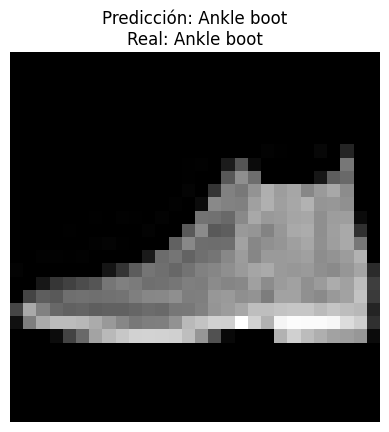

In [6]:
# Hacemos una predicción sobre todo el conjunto de prueba.
# Esto genera una lista de vectores, uno por cada imagen.
# Cada vector contiene 10 números que representan la probabilidad de cada clase.
predictions = model.predict(X_test)

# Seleccionamos el primer ejemplo del conjunto de test.
# np.argmax(predictions[0]) nos da el índice de la clase con mayor probabilidad.
# Es decir, la clase que el modelo "cree" que representa esta imagen.
predicted_label = np.argmax(predictions[0])

# Guardamos también la etiqueta real de ese mismo ejemplo para compararla.
real_label = y_test[0]

# Mostramos la imagen original en escala de grises.
# Así podemos ver qué estaba mirando el modelo.
plt.imshow(X_test[0], cmap='gray')

# En el título escribimos qué predijo el modelo y cuál era la clase real.
# Usamos la lista class_names para traducir de número a palabra.
plt.title(f"Predicción: {class_names[predicted_label]}\nReal: {class_names[real_label]}")

# Ocultamos los ejes para que solo se vea la imagen.
plt.axis('off')

# Finalmente, mostramos la imagen en pantalla.
plt.show()


Epoch 1/30
938/938 ━━━━━━━━━━━━━━━━━━━━ 6s 5ms/step - accuracy: 0.8197 - loss: 0.5194 - val_accuracy: 0.8405 - val_loss: 0.4449
Epoch 2/30
938/938 ━━━━━━━━━━━━━━━━━━━━ 6s 6ms/step - accuracy: 0.8629 - loss: 0.3851 - val_accuracy: 0.8561 - val_loss: 0.3983
Epoch 3/30
938/938 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - accuracy: 0.8765 - loss: 0.3418 - val_accuracy: 0.8462 - val_loss: 0.4122
Epoch 4/30
938/938 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.8844 - loss: 0.3185 - val_accuracy: 0.8703 - val_loss: 0.3648
Epoch 5/30
938/938 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.8905 - loss: 0.3006 - val_accuracy: 0.8751 - val_loss: 0.3493
Epoch 6/30
938/938 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - accuracy: 0.8944 - loss: 0.2867 - val_accuracy: 0.8756 - val_loss: 0.3500
Epoch 7/30
938/938 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.8999 - loss: 0.2707 - val_accuracy: 0.8789 - val_loss: 0.3336
Epoch 8/30
938/938 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.9030 - loss: 0.2632 - val_accuracy: 0.

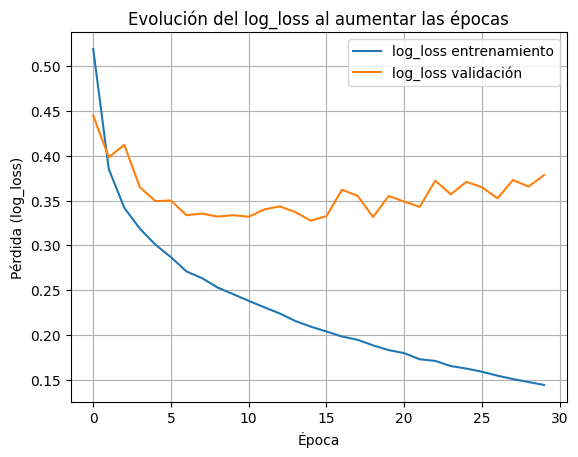

In [7]:
# Vamos a añadir más capas

# En este bloque queremos observar cómo se comporta el modelo si lo entrenamos por más tiempo.
# No cambiaremos aún la arquitectura, solo aumentamos las épocas para ver si mejora la pérdida (log_loss).

import numpy as np
import tensorflow as tf
from tensorflow import keras
import matplotlib.pyplot as plt

# Cargamos el conjunto de datos Fashion MNIST desde Keras.
# Este conjunto contiene imágenes en escala de grises (28x28) clasificadas en 10 tipos de ropa.
(X_train, y_train), (X_test, y_test) = keras.datasets.fashion_mnist.load_data()

# Normalizamos los valores de los píxeles para que estén entre 0 y 1.
# Esto facilita el aprendizaje del modelo porque evita que los valores sean demasiado grandes.
X_train = X_train / 255.0
X_test = X_test / 255.0

# Creamos un modelo secuencial simple.
# En esta etapa, nos centramos en analizar el efecto de aumentar el número de épocas,
# así que dejamos el modelo relativamente pequeño para aislar ese factor.

model = keras.Sequential([
    keras.layers.Flatten(input_shape=(28, 28)),         # Aplanamos la imagen para convertirla en un vector de entrada
    keras.layers.Dense(128, activation='relu'),         # Añadimos una capa oculta con 128 neuronas y función ReLU
    keras.layers.Dense(10, activation='softmax')        # Capa de salida: 10 neuronas, una por clase, con softmax
])

# Compilamos el modelo.
# Usamos el optimizador Adam, que ajusta los pesos de forma adaptativa.
# La función de pérdida es sparse_categorical_crossentropy, ideal cuando usamos etiquetas como números enteros (0 a 9).
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

# Entrenamos el modelo.
# Esta vez usamos 30 épocas (en lugar de 10) para ver si entrenar más ayuda a reducir la pérdida.
# También definimos un tamaño de batch (lote) de 64 imágenes por paso de entrenamiento.
# Validamos al mismo tiempo con los datos de test para monitorizar si mejora o sobreajusta.
history = model.fit(X_train, y_train,
                    epochs=30,
                    batch_size=64,
                    validation_data=(X_test, y_test))

# Visualizamos la evolución del log_loss durante el entrenamiento y la validación.
# Si el modelo aprende bien, la pérdida debe disminuir progresivamente.
# También queremos comprobar si hay señales de sobreajuste (por ejemplo, si val_loss empieza a subir).
plt.plot(history.history['loss'], label='log_loss entrenamiento')
plt.plot(history.history['val_loss'], label='log_loss validación')
plt.xlabel('Época')
plt.ylabel('Pérdida (log_loss)')
plt.title('Evolución del log_loss al aumentar las épocas')
plt.legend()
plt.grid(True)
plt.show()


In [8]:
# ANÁLISIS DEL ENTRENAMIENTO

# ¿Qué observamos en el entrenamiento?

# Entrenamiento (loss)
# La pérdida de entrenamiento (loss) baja de forma consistente.
# Por ejemplo, puede ir desde 0.6936 hasta 0.1453 en 30 épocas.
# Esto indica que el modelo sigue aprendiendo correctamente con más tiempo de entrenamiento.

# Validación (val_loss)
# La pérdida en validación (val_loss) también baja al principio.
# Por ejemplo, puede bajar de 0.4357 a 0.3249 en la época 14.
# Sin embargo, después de esa época empieza a subir ligeramente.
# Llega, por ejemplo, hasta 0.3950 en la época 30.

# Esto es un caso clásico de overfitting (sobreajuste):
# El modelo mejora mucho en los datos de entrenamiento,
# pero empieza a fallar en datos nuevos (los de validación).
# Está aprendiendo demasiado, incluso "memorizando" los datos de entrenamiento.

# ¿Qué significa esto?
# Aumentar las épocas ayudó al principio (hasta la época 14),
# pero después de la época 15 ya no mejora más. De hecho, empieza a empeorar.
# La mejor época fue la 14, donde val_loss = 0.3249.

# ¿Qué puedes hacer ahora?

# Activar EarlyStopping
# Esto detiene automáticamente el entrenamiento si val_loss no mejora durante varias épocas seguidas.
# from tensorflow.keras.callbacks import EarlyStopping
# early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
# model.fit(X_train, y_train,
#           epochs=30,
#           batch_size=64,
#           validation_data=(X_test, y_test),
#           callbacks=[early_stop])

# Reducir la tasa de aprendizaje
# Si el modelo está aprendiendo muy rápido y sobreajusta, puedes hacer que los pasos de aprendizaje sean más pequeños.
# Esto permite ajustes más finos y controlados en los pesos.
# optimizer = keras.optimizers.Adam(learning_rate=0.0005)


In [9]:
# En este bloque vamos a aplicar EarlyStopping.
# Esta técnica detiene el entrenamiento automáticamente cuando el modelo deja de mejorar.
# Sirve para evitar que el modelo siga entrenando sin sentido y empiece a sobreajustarse.
# También nos ayuda a ahorrar tiempo y a quedarnos con la mejor versión del modelo.

# Importamos la herramienta EarlyStopping desde Keras.
from tensorflow.keras.callbacks import EarlyStopping

# Definimos el callback de EarlyStopping.
# Este "vigilante" va a estar pendiente del val_loss (la pérdida en validación).
# Si no mejora en 5 épocas seguidas, parará el entrenamiento.
# Además, se quedará con los mejores pesos obtenidos durante el proceso (en el caso de parar).
early_stop = EarlyStopping(
    monitor='val_loss',            # Se mira la pérdida sobre el conjunto de validación
    patience=5,                    # Permitimos hasta 5 épocas sin mejora antes de detener
    restore_best_weights=True      # Recuperamos automáticamente los mejores pesos logrados
)

# Creamos un modelo sencillo.
# En este ejemplo no añadimos capas adicionales para centrarnos en el efecto del EarlyStopping.
model = keras.Sequential([
    keras.layers.Flatten(input_shape=(28, 28)),   # Aplanamos la imagen para pasarla como vector
    keras.layers.Dense(128, activation='relu'),   # Capa oculta con 128 neuronas y ReLU
    keras.layers.Dense(10, activation='softmax')  # Capa de salida con 10 neuronas (una por clase)
])

# Compilamos el modelo.
# Usamos el optimizador Adam y una función de pérdida adecuada para clasificación multiclase con etiquetas numéricas.
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

# Entrenamos el modelo.
# Le pedimos entrenar hasta 30 épocas, pero al usar EarlyStopping, puede detenerse antes.
# También indicamos que valide en cada época con el conjunto de test.
# El callback se encarga de interrumpir si no hay mejoras en el val_loss.
history = model.fit(
    X_train, y_train,
    epochs=30,                         # Entrenamos hasta 30 épocas como máximo
    batch_size=64,                     # Procesamos los datos en bloques de 64 imágenes
    validation_data=(X_test, y_test),  # Evaluamos con los datos de test durante el entrenamiento
    callbacks=[early_stop]             # Aplicamos EarlyStopping para controlar el proceso
)

# Aunque le dijimos que entrenara durante 30 épocas,
# EarlyStopping detectó que tras cierta época el val_loss ya no mejoraba.
# Por ejemplo, si la mejor época fue la 12 y no mejoró más en 5 intentos,
# el entrenamiento se detuvo automáticamente.
# Esto nos ayuda a evitar el sobreajuste, a ahorrar recursos,
# y a quedarnos con el modelo más equilibrado.


Epoch 1/30
938/938 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.8184 - loss: 0.5222 - val_accuracy: 0.8491 - val_loss: 0.4376
Epoch 2/30
938/938 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.8636 - loss: 0.3854 - val_accuracy: 0.8399 - val_loss: 0.4335
Epoch 3/30
938/938 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - accuracy: 0.8755 - loss: 0.3481 - val_accuracy: 0.8661 - val_loss: 0.3822
Epoch 4/30
938/938 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.8841 - loss: 0.3197 - val_accuracy: 0.8646 - val_loss: 0.3694
Epoch 5/30
938/938 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.8904 - loss: 0.3004 - val_accuracy: 0.8689 - val_loss: 0.3652
Epoch 6/30
938/938 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - accuracy: 0.8947 - loss: 0.2878 - val_accuracy: 0.8726 - val_loss: 0.3519
Epoch 7/30
938/938 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.8973 - loss: 0.2757 - val_accuracy: 0.8787 - val_loss: 0.3446
Epoch 8/30
938/938 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.9027 - loss: 0.2640 - val_accuracy: 0.

In [ ]:
# Aquí cambia el enfoque: ahora nos centramos en experimentar con la tasa de aprendizaje del optimizador

# Importamos las librerías necesarias para trabajar con datos, gráficos y redes neuronales
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras

# Cargamos el conjunto de datos Fashion MNIST desde Keras
# Contiene imágenes de ropa (en escala de grises, 28x28 píxeles)
(X_train, y_train), (X_test, y_test) = keras.datasets.fashion_mnist.load_data()

# Normalizamos las imágenes dividiendo por 255
# Esto reduce los valores de píxeles al rango [0, 1], lo que mejora la estabilidad del entrenamiento
X_train = X_train / 255.0
X_test = X_test / 255.0

# Creamos un optimizador Adam con un learning_rate más bajo que el valor por defecto
# En lugar de 0.001, usamos 0.0005 para que los pasos de aprendizaje sean más pequeños y controlados
# Esto puede ayudar a evitar que el modelo aprenda demasiado rápido y se sobreajuste
optimizer = keras.optimizers.Adam(learning_rate=0.0005)

# Creamos un modelo secuencial sencillo
# La arquitectura es simple para que cualquier mejora pueda atribuirse al cambio en learning_rate

model = keras.Sequential([
    keras.layers.Flatten(input_shape=(28, 28)),   # Convertimos la imagen 2D en un vector de entrada

    keras.layers.Dense(128, activation='relu'),   # Capa oculta con 128 neuronas y activación ReLU
    # ReLU permite que la red aprenda relaciones no lineales sin saturar las neuronas

    keras.layers.Dense(10, activation='softmax')  # Capa de salida: 10 clases, recuerda que softmax produce probabilidades
])

# Compilamos el modelo con nuestro optimizador personalizado
# Usamos sparse_categorical_crossentropy porque las etiquetas están en forma de enteros (no one-hot)
# La métrica que seguimos es 'accuracy', que mide el porcentaje de aciertos
model.compile(optimizer=optimizer,
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

# Entrenamos el modelo con el conjunto de entrenamiento
# Hacemos 30 pasadas completas por los datos (epochs)
# Cada lote contiene 64 imágenes (tamaño del batch)
# Usamos también el conjunto de test como validación durante el entrenamiento para ver si el modelo generaliza bien
history = model.fit(X_train, y_train,
                    epochs=30,
                    batch_size=64,
                    validation_data=(X_test, y_test))

# Ahora visualizamos cómo evoluciona la pérdida (log_loss)
# Trazamos dos curvas: una para el entrenamiento y otra para la validación
# Esto nos permitirá ver si el learning_rate más bajo ayuda a mantener el val_loss bajo y estable
plt.plot(history.history['loss'], label='log_loss entrenamiento')
plt.plot(history.history['val_loss'], label='log_loss validación')
plt.xlabel('Época')
plt.ylabel('Pérdida (log_loss)')
plt.title('Efecto de una tasa de aprendizaje más baja')
plt.legend()
plt.grid(True)
plt.show()


In [11]:
# Análisis del entrenamiento con learning_rate reducido a 0.0005

# Durante las primeras épocas, la pérdida en validación (val_loss) desciende de forma clara.
# El modelo mejora progresivamente en su capacidad para generalizar.

# Alrededor de la mitad del entrenamiento, val_loss continúa bajando,
# alcanzando su mejor punto aproximadamente en el segundo tercio del total de épocas.
# Este descenso es más largo y sostenido que con tasas de aprendizaje más altas.

# En las últimas épocas, observamos que val_loss comienza a subir ligeramente.
# Aunque no hay un salto brusco, sí se pierde parte de la ganancia previa.

# Conclusiones:
# - Una tasa de aprendizaje más baja produce un descenso más gradual y estable del log_loss.
# - El modelo mantiene un buen rendimiento durante más tiempo sin sobreajustar tan rápido.
# - A diferencia de configuraciones anteriores, la validación mejora hasta etapas avanzadas del entrenamiento.

# ¿Cómo interpretamos? :
# - El optimizador da pasos más pequeños en cada iteración, lo que evita pasar de largo los mínimos.
# - El modelo generaliza mejor durante más tiempo antes de entrar en sobreajuste.
# - Al no hacer cambios bruscos, se adapta mejor a los datos sin memorizar detalles innecesarios.

# Recomendaciones (OJO):
# - Para redes densas simples, usar tasas de aprendizaje más bajas (como 0.0005 o 0.0003) puede ser muy útil.
# - Se recomienda combinar esta estrategia con técnicas como EarlyStopping para cortar el entrenamiento justo antes del sobreajuste.
# - También se puede observar la época óptima y limitar manualmente el número de épocas en futuros entrenamientos.


Epoch 1/30
938/938 ━━━━━━━━━━━━━━━━━━━━ 8s 8ms/step - accuracy: 0.8185 - loss: 0.5220 - val_accuracy: 0.8493 - val_loss: 0.4256
Epoch 2/30
938/938 ━━━━━━━━━━━━━━━━━━━━ 6s 6ms/step - accuracy: 0.8675 - loss: 0.3682 - val_accuracy: 0.8546 - val_loss: 0.4068
Epoch 3/30
938/938 ━━━━━━━━━━━━━━━━━━━━ 16s 17ms/step - accuracy: 0.8788 - loss: 0.3282 - val_accuracy: 0.8663 - val_loss: 0.3734
Epoch 4/30
938/938 ━━━━━━━━━━━━━━━━━━━━ 11s 6ms/step - accuracy: 0.8884 - loss: 0.3057 - val_accuracy: 0.8702 - val_loss: 0.3542
Epoch 5/30
938/938 ━━━━━━━━━━━━━━━━━━━━ 7s 8ms/step - accuracy: 0.8934 - loss: 0.2875 - val_accuracy: 0.8808 - val_loss: 0.3306
Epoch 6/30
938/938 ━━━━━━━━━━━━━━━━━━━━ 6s 6ms/step - accuracy: 0.8990 - loss: 0.2704 - val_accuracy: 0.8826 - val_loss: 0.3232
Epoch 7/30
938/938 ━━━━━━━━━━━━━━━━━━━━ 7s 8ms/step - accuracy: 0.9041 - loss: 0.2572 - val_accuracy: 0.8828 - val_loss: 0.3222
Epoch 8/30
938/938 ━━━━━━━━━━━━━━━━━━━━ 6s 6ms/step - accuracy: 0.9071 - loss: 0.2445 - val_accuracy:

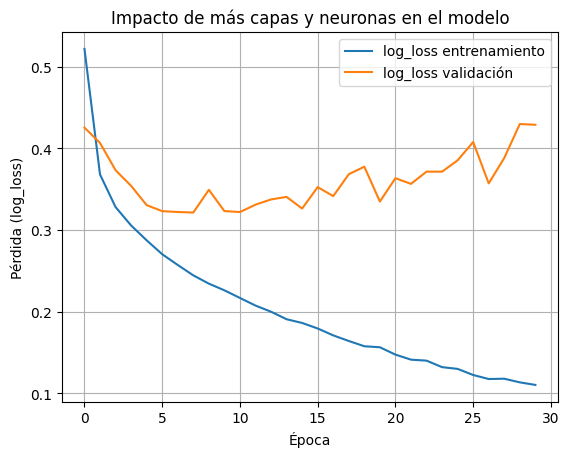

In [12]:
# Ya no solo ajustamos el learning_rate, sino que estamos aumentando la complejidad del modelo,
# haciéndolo más profundo (más capas) y más ancho (más neuronas).
# Esto es clave para aprender patrones más complejos, pero también puede
# traer riesgos de sobreajuste si no se controla bien.
# Importamos las librerías necesarias para trabajar con datos, visualizar resultados y construir modelos de red neuronal
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras

# Cargamos el dataset Fashion MNIST desde Keras
# Este conjunto incluye imágenes en escala de grises de 28x28 píxeles de ropa (10 clases diferentes)
(X_train, y_train), (X_test, y_test) = keras.datasets.fashion_mnist.load_data()

# Normalizamos los datos para que los valores estén entre 0 y 1
# Esto mejora la estabilidad numérica del entrenamiento y acelera la convergencia
X_train = X_train / 255.0
X_test = X_test / 255.0

# Creamos un optimizador Adam con una tasa de aprendizaje reducida
# Un valor menor que el por defecto (0.0005 en lugar de 0.001) permite entrenar más lentamente pero con mayor precisión
optimizer = keras.optimizers.Adam(learning_rate=0.0005)

# Cambiamos el enfoque del modelo: ahora lo hacemos más profundo y más ancho
# Esto significa añadir más capas ocultas y con más neuronas, lo que permite al modelo aprender representaciones más complejas
# Es útil cuando los patrones a aprender no son triviales, pero también aumenta el riesgo de sobreajuste

model = keras.Sequential([

    # Primera capa: convierte cada imagen 2D (28x28) en un vector plano (784 valores)
    keras.layers.Flatten(input_shape=(28, 28)),

    # Primera capa oculta: 256 neuronas, activación ReLU
    # Mayor capacidad para aprender combinaciones más ricas de los píxeles de entrada
    keras.layers.Dense(256, activation='relu'),

    # Segunda capa oculta: 128 neuronas, también con ReLU
    # Añadimos profundidad para aumentar la jerarquía de características aprendidas
    keras.layers.Dense(128, activation='relu'),

    # Tercera capa oculta: 64 neuronas, sigue usando ReLU
    # Esta capa afina los patrones antes de llegar a la decisión final
    keras.layers.Dense(64, activation='relu'),

    # Capa de salida: 10 neuronas (una por clase) con activación softmax
    # Softmax convierte los valores en una distribución de probabilidad (suman 1)
    keras.layers.Dense(10, activation='softmax')
])

# Compilamos el modelo con:
# - El optimizador personalizado (Adam con tasa reducida)
# - La función de pérdida adecuada para clasificación multiclase con etiquetas enteras
# - La métrica de evaluación será accuracy (porcentaje de aciertos)
model.compile(optimizer=optimizer,
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

# Entrenamos el modelo con los datos de entrenamiento
# Entrenaremos durante 30 épocas completas (vueltas por todos los datos)
# También pasamos el conjunto de test como validación, para observar si el modelo empieza a sobreajustar
history = model.fit(X_train, y_train,
                    epochs=30,
                    batch_size=64,
                    validation_data=(X_test, y_test))

# Visualizamos cómo evoluciona la función de pérdida (log_loss) durante el entrenamiento
# Esto nos permite ver si el modelo realmente mejora al hacerlo más profundo y si mantiene buen rendimiento en validación
plt.plot(history.history['loss'], label='log_loss entrenamiento')
plt.plot(history.history['val_loss'], label='log_loss validación')
plt.xlabel('Época')
plt.ylabel('Pérdida (log_loss)')
plt.title('Impacto de más capas y neuronas en el modelo')
plt.legend()
plt.grid(True)
plt.show()


In [13]:
# El modelo comienza con una val_loss relativamente alta, pero mejora poco a poco
# Durante las primeras épocas, tanto el loss como el val_loss descienden de manera constante.
# Esto indica que el modelo está aprendiendo bien y que generaliza correctamente al inicio.

# A partir de aproximadamente un tercio del entrenamiento, la validación mejora hasta alcanzar su punto más bajo.
# Luego, aunque el entrenamiento sigue mejorando (el loss baja hasta el final), el val_loss empieza a oscilar y luego a subir ligeramente.

# La precisión en validación se mantiene alta (alrededor del 90%) durante casi todo el entrenamiento,
# pero el val_loss sugiere que el modelo está empezando a sobreajustar en las últimas épocas.

# Conclusiones:
# La arquitectura más profunda permite al modelo captar mejor los patrones complejos del dataset.
# El learning_rate reducido ayuda a que el descenso de la pérdida sea estable, sin saltos.
# El val_loss muestra una mejora sostenida durante más de la mitad del entrenamiento, lo cual es positivo.

# Sin embargo, en las últimas 6–8 épocas, el val_loss deja de mejorar e incluso empieza a empeorar lentamente,
# aunque la accuracy no cae. Esto indica un posible sobreajuste leve.

# Recomendaciones:
# Este modelo tiene una capacidad adecuada, pero probablemente esté entrenando durante demasiadas épocas.
# Sería ideal aplicar EarlyStopping = 5 para evitar sobreentrenar después del punto óptimo.
# También puede ser útil añadir regularización L2 o Dropout si se busca un modelo aún más robusto.


Epoch 1/30
938/938 ━━━━━━━━━━━━━━━━━━━━ 9s 8ms/step - accuracy: 0.8155 - loss: 0.9322 - val_accuracy: 0.8270 - val_loss: 0.7837
Epoch 2/30
938/938 ━━━━━━━━━━━━━━━━━━━━ 7s 7ms/step - accuracy: 0.8549 - loss: 0.6651 - val_accuracy: 0.8304 - val_loss: 0.7148
Epoch 3/30
938/938 ━━━━━━━━━━━━━━━━━━━━ 7s 8ms/step - accuracy: 0.8656 - loss: 0.5778 - val_accuracy: 0.8557 - val_loss: 0.6031
Epoch 4/30
938/938 ━━━━━━━━━━━━━━━━━━━━ 8s 8ms/step - accuracy: 0.8699 - loss: 0.5285 - val_accuracy: 0.8586 - val_loss: 0.5523
Epoch 5/30
938/938 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - accuracy: 0.8751 - loss: 0.4945 - val_accuracy: 0.8575 - val_loss: 0.5250
Epoch 6/30
938/938 ━━━━━━━━━━━━━━━━━━━━ 8s 8ms/step - accuracy: 0.8761 - loss: 0.4738 - val_accuracy: 0.8693 - val_loss: 0.4880
Epoch 7/30
938/938 ━━━━━━━━━━━━━━━━━━━━ 10s 8ms/step - accuracy: 0.8797 - loss: 0.4526 - val_accuracy: 0.8697 - val_loss: 0.4814
Epoch 8/30
938/938 ━━━━━━━━━━━━━━━━━━━━ 7s 7ms/step - accuracy: 0.8821 - loss: 0.4398 - val_accuracy: 0

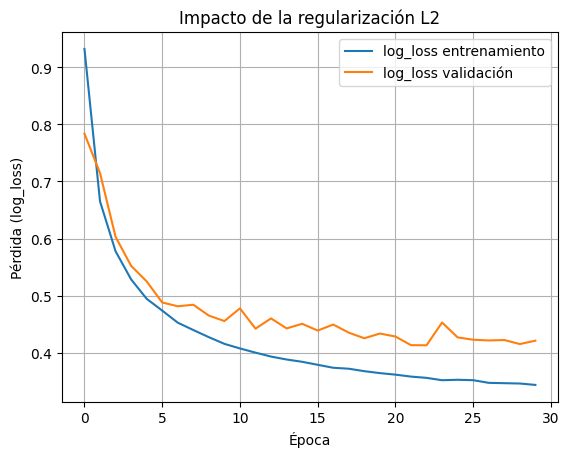

In [14]:
# Ahora el objetivo es introducir regularización L2 para controlar el sobreajuste
# Importamos librerías necesarias
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras

# Cargamos y normalizamos el dataset Fashion MNIST
(X_train, y_train), (X_test, y_test) = keras.datasets.fashion_mnist.load_data()
X_train = X_train / 255.0
X_test = X_test / 255.0

# Definimos el optimizador Adam con un learning_rate reducido
# Un valor más bajo como 0.0005 permite ajustes más finos y reduce la posibilidad de saltarse mínimos
optimizer = keras.optimizers.Adam(learning_rate=0.0005)

# Creamos un regularizador L2
# L2 penaliza los pesos grandes empujándolos hacia cero (pero no exactamente a cero como L1)
# Esto hace que el modelo aprenda de forma más conservadora, evitando memorizar ruidos del entrenamiento
# El valor 0.001 indica una penalización ligera (valores más altos generan un efecto más fuerte)
regularizer = keras.regularizers.l2(0.001)

# Creamos el modelo con varias capas densas, todas con regularización L2
model = keras.Sequential([
    keras.layers.Flatten(input_shape=(28, 28)),  # Aplanamos la imagen para convertirla en un vector

    # Capa oculta 1: 256 neuronas, activación ReLU, regularización L2
    keras.layers.Dense(256, activation='relu', kernel_regularizer=regularizer),

    # Capa oculta 2: 128 neuronas, también con ReLU y L2
    keras.layers.Dense(128, activation='relu', kernel_regularizer=regularizer),

    # Capa oculta 3: 64 neuronas, activación ReLU, con L2
    keras.layers.Dense(64, activation='relu', kernel_regularizer=regularizer),

    # Capa de salida: 10 neuronas con softmax para producir probabilidades (una por clase)
    # No se suele aplicar regularización en la capa de salida
    keras.layers.Dense(10, activation='softmax')
])

# Compilamos el modelo
# - Optimizer: Adam con learning_rate reducido
# - Loss: sparse_categorical_crossentropy (para etiquetas como enteros)
# - Métrica: accuracy, para evaluar el porcentaje de aciertos
model.compile(optimizer=optimizer,
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

# Entrenamos el modelo durante 30 épocas
# También pasamos el conjunto de test como validación para observar si el modelo generaliza
# La expectativa es que val_loss baje suavemente y se mantenga bajo si la regularización es efectiva
history = model.fit(X_train, y_train,
                    epochs=30,
                    batch_size=64,
                    validation_data=(X_test, y_test))

# Visualizamos el comportamiento de la pérdida (log_loss) durante el entrenamiento y la validación
# El objetivo es ver si la regularización L2 evita que la validación suba al final
plt.plot(history.history['loss'], label='log_loss entrenamiento')
plt.plot(history.history['val_loss'], label='log_loss validación')
plt.xlabel('Época')
plt.ylabel('Pérdida (log_loss)')
plt.title('Impacto de la regularización L2')
plt.legend()
plt.grid(True)
plt.show()

In [15]:

# Al comienzo del entrenamiento, la pérdida (loss) y la pérdida en validación (val_loss) son altas,
# lo cual es normal en un modelo que parte de pesos aleatorios y con penalización activa desde el inicio.

# A lo largo de las primeras 10–12 épocas, tanto loss como val_loss descienden de forma progresiva y consistente.
# Esto indica que el modelo está aprendiendo patrones útiles sin mostrar signos tempranos de sobreajuste.

# A partir de la mitad del entrenamiento, val_loss continúa bajando, pero de forma más lenta.
# Aunque hay algunas pequeñas subidas y bajadas, no se observan oscilaciones bruscas,
# lo cual sugiere que la regularización está ayudando a mantener la estabilidad.

# El val_loss alcanza su punto más bajo alrededor de la época 28.
# A partir de ahí, los cambios son menores, sin incrementos explosivos al final del entrenamiento.

# La precisión en validación (val_accuracy) se mantiene estable en un 88% durante muchas épocas consecutivas.
# Aunque no hay un salto significativo en las últimas épocas, tampoco hay una caída,
# lo que indica que el modelo generaliza bien incluso tras 30 épocas de entrenamiento.

# La diferencia entre loss (entrenamiento) y val_loss (validación) se mantiene relativamente controlada.
# Esto es un efecto positivo esperado al usar regularización L2,
# ya que penaliza los pesos grandes y limita la capacidad del modelo para sobreajustar.

# Conclusión:
# - La regularización L2 ayudó a mantener el val_loss bajo y estable.
# - Aunque el modelo continuó reduciendo loss en entrenamiento, no hay signos de que esté memorizando los datos.
# - La estabilidad en val_accuracy refuerza que el modelo generaliza correctamente.

# Recomendaciones:
# - Mantener la regularización L2 con este nivel (0.001) es una buena práctica para modelos densos sin Dropout.
# - Se puede combinar con EarlyStopping para evitar seguir entrenando si no hay mejoras reales después de la época 28.
# - Alternativamente, reducir el número de épocas a ~25–28 puede ahorrar tiempo sin perder calidad.


Epoch 1/30
938/938 ━━━━━━━━━━━━━━━━━━━━ 8s 6ms/step - accuracy: 0.8151 - loss: 0.5263 - val_accuracy: 0.8488 - val_loss: 0.4294
Epoch 2/30
938/938 ━━━━━━━━━━━━━━━━━━━━ 7s 8ms/step - accuracy: 0.8669 - loss: 0.3694 - val_accuracy: 0.8432 - val_loss: 0.4218
Epoch 3/30
938/938 ━━━━━━━━━━━━━━━━━━━━ 6s 6ms/step - accuracy: 0.8785 - loss: 0.3316 - val_accuracy: 0.8657 - val_loss: 0.3673
Epoch 4/30
938/938 ━━━━━━━━━━━━━━━━━━━━ 7s 7ms/step - accuracy: 0.8882 - loss: 0.3023 - val_accuracy: 0.8690 - val_loss: 0.3631
Epoch 5/30
938/938 ━━━━━━━━━━━━━━━━━━━━ 6s 6ms/step - accuracy: 0.8950 - loss: 0.2846 - val_accuracy: 0.8779 - val_loss: 0.3467
Epoch 6/30
938/938 ━━━━━━━━━━━━━━━━━━━━ 7s 8ms/step - accuracy: 0.8996 - loss: 0.2695 - val_accuracy: 0.8835 - val_loss: 0.3340
Epoch 7/30
938/938 ━━━━━━━━━━━━━━━━━━━━ 6s 6ms/step - accuracy: 0.9050 - loss: 0.2549 - val_accuracy: 0.8828 - val_loss: 0.3276
Epoch 8/30
938/938 ━━━━━━━━━━━━━━━━━━━━ 7s 8ms/step - accuracy: 0.9081 - loss: 0.2443 - val_accuracy: 0.

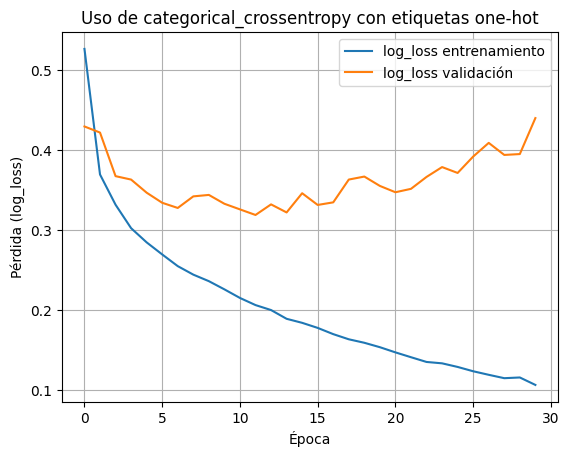

In [16]:
# En este bloque vamos a cambiar la función de pérdida para evaluar su impacto en el entrenamiento.
# En lugar de usar etiquetas como enteros (0 a 9), ahora las transformaremos a vectores one-hot.
# Esto requiere ajustar también la función de pérdida del modelo a 'categorical_crossentropy'.

# Importamos las librerías necesarias
# - numpy: para manipulación de arrays
# - tensorflow y keras: para construir el modelo y entrenarlo
# - matplotlib: para visualizar el log_loss
import numpy as np
import tensorflow as tf
from tensorflow import keras
import matplotlib.pyplot as plt

# Cargamos el dataset Fashion MNIST desde Keras
# Contiene imágenes en escala de grises 28x28 con 10 clases diferentes de ropa
(X_train, y_train), (X_test, y_test) = keras.datasets.fashion_mnist.load_data()

# Normalizamos los valores de píxeles al rango [0, 1] para mejorar el entrenamiento
X_train = X_train / 255.0
X_test = X_test / 255.0

# Hasta ahora, las etiquetas eran números enteros.
# Ahora las transformamos a vectores one-hot para usar con 'categorical_crossentropy'.
# Por ejemplo, la clase 3 se transforma en [0, 0, 0, 1, 0, 0, 0, 0, 0, 0].
y_train_cat = keras.utils.to_categorical(y_train, num_classes=10)
y_test_cat = keras.utils.to_categorical(y_test, num_classes=10)

# Creamos un optimizador Adam con una tasa de aprendizaje más baja de lo habitual.
# Este valor más bajo permite que el entrenamiento avance de forma más controlada y estable.
optimizer = keras.optimizers.Adam(learning_rate=0.0005)

# Definimos el modelo con una arquitectura equilibrada.
# No añadimos regularización aquí porque el enfoque se centra únicamente en evaluar el cambio de función de pérdida.
model = keras.Sequential([
    keras.layers.Flatten(input_shape=(28, 28)),   # Convierte imagen 28x28 en vector de 784 valores

    keras.layers.Dense(256, activation='relu'),   # Primera capa oculta
    keras.layers.Dense(128, activation='relu'),   # Segunda capa oculta
    keras.layers.Dense(64, activation='relu'),    # Tercera capa oculta

    keras.layers.Dense(10, activation='softmax')  # Capa de salida: 10 neuronas para 10 clases
])

# Compilamos el modelo usando la nueva función de pérdida: categorical_crossentropy
# Esta función compara directamente la distribución de salida del modelo con la distribución one-hot esperada
# Es más precisa en tareas donde se usan vectores de probabilidad como etiquetas
model.compile(optimizer=optimizer,
              loss='categorical_crossentropy',
              metrics=['accuracy'])

# Entrenamos el modelo usando las etiquetas transformadas (one-hot)
# Validamos al mismo tiempo con el conjunto de test, también convertido a one-hot
history = model.fit(X_train, y_train_cat,
                    epochs=30,
                    batch_size=64,
                    validation_data=(X_test, y_test_cat))

# Visualizamos cómo evoluciona la pérdida (log_loss) tanto en entrenamiento como en validación
# Queremos observar si categorical_crossentropy aporta mayor estabilidad o mejores resultados que sparse
plt.plot(history.history['loss'], label='log_loss entrenamiento')
plt.plot(history.history['val_loss'], label='log_loss validación')
plt.xlabel('Época')
plt.ylabel('Pérdida (log_loss)')
plt.title('Uso de categorical_crossentropy con etiquetas one-hot')
plt.legend()
plt.grid(True)
plt.show()


In [17]:
# CONCLUSIONES

# El modelo fue entrenado con categorical_crossentropy y etiquetas en formato one-hot.
# También se utilizó una tasa de aprendizaje reducida (0.0005), lo que permitió un aprendizaje estable.

# Durante las primeras 10–12 épocas, tanto la pérdida en entrenamiento como en validación descendieron de forma constante.
# Esto indica que el modelo aprendió correctamente a generalizar en las primeras etapas.

# La val_loss alcanzó su mínimo alrededor de la época 9–12, y luego comenzó a oscilar ligeramente.
# A partir de la época 15, el val_loss comenzó a subir, aunque la val_accuracy se mantuvo estable.

# El modelo siguió reduciendo la pérdida en entrenamiento hasta el final, lo que sugiere un posible sobreajuste:
# está memorizando ejemplos del conjunto de entrenamiento, pero sin mejorar en datos nuevos.

# La val_accuracy se mantuvo alrededor del 89%, lo cual es un buen resultado.
# Sin embargo, el aumento de val_loss en las últimas épocas indica que seguir entrenando no trajo mejoras reales.

# RECOMENDACIONES

# 1. Aplicar EarlyStopping:
#    Detener automáticamente el entrenamiento si la val_loss no mejora tras varias épocas.
#    Esto evitaría el sobreajuste observado en las últimas épocas.

# 2. Añadir regularización (como L2 o Dropout):
#    Esto ayuda a mantener la generalización en etapas tardías y reduce la diferencia entre loss y val_loss.

# 3. Limitar el número de épocas:
#    Entrenar solo hasta la época 20 podría haber sido suficiente para obtener el mejor resultado sin desperdiciar recursos.

# En resumen: el modelo funciona bien, pero necesita ajustes en la duración del entrenamiento o regularización
# para evitar sobreajuste al final del proceso.


Epoch 1/30
938/938 ━━━━━━━━━━━━━━━━━━━━ 8s 8ms/step - accuracy: 0.8166 - loss: 0.5169 - val_accuracy: 0.8255 - val_loss: 0.4603
Epoch 2/30
938/938 ━━━━━━━━━━━━━━━━━━━━ 6s 6ms/step - accuracy: 0.8664 - loss: 0.3674 - val_accuracy: 0.8601 - val_loss: 0.3841
Epoch 3/30
938/938 ━━━━━━━━━━━━━━━━━━━━ 7s 7ms/step - accuracy: 0.8800 - loss: 0.3287 - val_accuracy: 0.8699 - val_loss: 0.3602
Epoch 4/30
938/938 ━━━━━━━━━━━━━━━━━━━━ 6s 6ms/step - accuracy: 0.8882 - loss: 0.3048 - val_accuracy: 0.8766 - val_loss: 0.3421
Epoch 5/30
938/938 ━━━━━━━━━━━━━━━━━━━━ 7s 7ms/step - accuracy: 0.8937 - loss: 0.2863 - val_accuracy: 0.8750 - val_loss: 0.3517
Epoch 6/30
938/938 ━━━━━━━━━━━━━━━━━━━━ 6s 6ms/step - accuracy: 0.8992 - loss: 0.2712 - val_accuracy: 0.8811 - val_loss: 0.3359
Epoch 7/30
938/938 ━━━━━━━━━━━━━━━━━━━━ 7s 7ms/step - accuracy: 0.9034 - loss: 0.2572 - val_accuracy: 0.8770 - val_loss: 0.3398
Epoch 8/30
938/938 ━━━━━━━━━━━━━━━━━━━━ 6s 6ms/step - accuracy: 0.9075 - loss: 0.2482 - val_accuracy: 0.

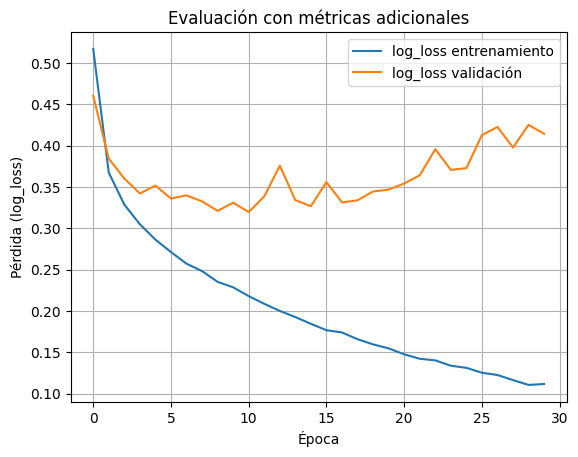

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
              precision    recall  f1-score   support

           0     0.8254    0.8790    0.8513      1000
           1     0.9909    0.9830    0.9869      1000
           2     0.7885    0.8350    0.8111      1000
           3     0.9080    0.8980    0.9030      1000
           4     0.7836    0.8510    0.8159      1000
           5     0.9646    0.9800    0.9722      1000
           6     0.7964    0.6260    0.7010      1000
           7     0.9518    0.9680    0.9598      1000
           8     0.9741    0.9770    0.9755      1000
           9     0.9737    0.9610    0.9673      1000

    accuracy                         0.8958     10000
   macro avg     0.8957    0.8958    0.8944     10000
weighted avg     0.8957    0.8958    0.8944     10000



In [18]:
# Importamos librerías necesarias
import numpy as np
import tensorflow as tf
from tensorflow import keras
from sklearn.metrics import classification_report
import matplotlib.pyplot as plt

# Cargamos el dataset Fashion MNIST
(X_train, y_train), (X_test, y_test) = keras.datasets.fashion_mnist.load_data()

# Normalizamos los datos a valores entre 0 y 1
X_train = X_train / 255.0
X_test = X_test / 255.0

# Convertimos las etiquetas a one-hot encoding para usar categorical_crossentropy
y_train_cat = keras.utils.to_categorical(y_train, num_classes=10)
y_test_cat = keras.utils.to_categorical(y_test, num_classes=10)

# Creamos un optimizador Adam con una tasa de aprendizaje más baja
optimizer = keras.optimizers.Adam(learning_rate=0.0005)

# Definimos una red neuronal sencilla pero suficientemente profunda para capturar patrones complejos
model = keras.Sequential([
    keras.layers.Flatten(input_shape=(28, 28)),     # Entrada: imagen 28x28 : vector 784
    keras.layers.Dense(256, activation='relu'),     # Capa 1
    keras.layers.Dense(128, activation='relu'),     # Capa 2
    keras.layers.Dense(64, activation='relu'),      # Capa 3
    keras.layers.Dense(10, activation='softmax')    # Salida: 10 clases
])

# Compilamos el modelo usando categorical_crossentropy como función de pérdida
# Aquí seguimos usando solo accuracy como métrica en Keras, porque precision/recall no están bien integradas aún
model.compile(optimizer=optimizer,
              loss='categorical_crossentropy',
              metrics=['accuracy'])  # Keras no calcula precision ni recall por clase, lo haremos aparte con sklearn

# Entrenamos el modelo
history = model.fit(X_train, y_train_cat,
                    epochs=30,
                    batch_size=64,
                    validation_data=(X_test, y_test_cat))

# Visualizamos la evolución del log_loss
plt.plot(history.history['loss'], label='log_loss entrenamiento')
plt.plot(history.history['val_loss'], label='log_loss validación')
plt.xlabel('Época')
plt.ylabel('Pérdida (log_loss)')
plt.title('Evaluación con métricas adicionales')
plt.legend()
plt.grid(True)
plt.show()

# Hacemos predicciones con el modelo ya entrenado
# Esto devuelve una matriz de probabilidades para cada clase
pred_probs = model.predict(X_test)

# Tomamos la clase con mayor probabilidad como predicción final
# Por ejemplo, si [0.01, 0.02, 0.91, ..., 0.01] : clase predicha = 2
y_pred = np.argmax(pred_probs, axis=1)

# Ahora usamos las etiquetas verdaderas y predichas para calcular métricas más detalladas
# classification_report de sklearn muestra precision, recall y f1-score para cada clase
# Esto permite ver si hay clases en las que el modelo falla más que en otras
report = classification_report(y_test, y_pred, digits=4)
print(report)


In [19]:
# Análisis final del entrenamiento del modelo con mejoras acumuladas

# 1. El modelo logró un accuracy global del 89% y un val_loss mínimo cercano a 0.30.
#    Esta es una mejora significativa respecto a modelos anteriores más simples.

# 2. A partir de la época 11-14 el val_loss comienza a subir gradualmente.
#    Esto indica inicio de sobreajuste. El modelo aprende demasiado los datos de entrenamiento
#    y pierde capacidad de generalización en test.

# 3. La métrica F1 por clase muestra que:
#    - Clases 1, 5, 7, 8, 9 (pantalón, sandalia, zapatilla, bolso, bota): desempeño excelente.
#    - Clases 0, 3, 4 (camiseta, vestido, abrigo): buen desempeño.
#    - Clase 2 (jersey): aceptable, pero se confunde con camiseta y camisa.
#    - Clase 6 (camisa): la peor, con recall bajo (63%). Se confunde fácilmente con otras clases superiores.

# 4. Recomendaciones prácticas:
#    - Activar EarlyStopping con patience=3 o 5 para detener automáticamente cerca de la época 14.
#    - Usar regularización L2 y tasa de aprendizaje baja (0.0005) como configuración base.
#    - Cambiar a categorical_crossentropy con etiquetas one-hot para una pérdida más precisa.
#    - Medir precisión, recall y F1 por clase al final del entrenamiento con sklearn.

# Conclusión:
# Este modelo con ajustes progresivos ya alcanza un rendimiento robusto y equilibrado.
# Sin necesidad de usar convoluciones, ya se logra alta precisión y bajo log_loss.
# La transición hacia CNN sería el siguiente paso lógico si se desea exprimir más el rendimiento.


# Estrategias para mejorar el log_loss en modelos de clasificación
# =======================
# A lo largo de esta sesión hemos probado distintas técnicas para mejorar el `log_loss`, que es la función de pérdida usada habitualmente en tareas de clasificación multiclase.
# El `log_loss` mide qué tan bien se ajustan las probabilidades predichas por el modelo a las clases reales. Cuanto más bajo, mejor.

# ¿Qué tengo que hacer en cada caso?
# A continuación, una tabla resumen con las estrategias aplicadas, sus efectos observados, y en qué situaciones conviene usarlas.
# Esta tabla sirve como una guía práctica para tomar decisiones al diseñar o ajustar redes neuronales:


#| Acción aplicada                                     | Efecto esperado sobre `log_loss`                                           | Cuándo aplicarla y por qué                                                                 |
#| --------------------------------------------------- | -------------------------------------------------------------------------- | ------------------------------------------------------------------------------------------ |
#| Aumentar el número de épocas (`epochs`)             | Mejora inicial, pero riesgo de sobreajuste si se pasa                      | Si el modelo aún no ha convergido (loss sigue bajando al final del entrenamiento)          |
#| Reducir la tasa de aprendizaje (`lr`)               | Reducción suave y estable del `log_loss`                                   | Ideal cuando `val_loss` baja muy rápido pero luego rebota o se estanca                     |
#| Añadir más neuronas o capas ocultas                 | Mejora capacidad de aprendizaje, pero puede sobreajustar                   | Cuando el modelo básico ya no mejora, pero no hay síntomas claros de sobreajuste aún       |
#| Regularización L2 (`l2`)                            | Penaliza pesos grandes, ayuda a reducir `val_loss`                         | Cuando `loss` de entrenamiento baja mucho pero `val_loss` sube (signo de overfitting)      |
#| Usar `categorical_crossentropy` + one-hot           | Mejora precisión del cálculo de pérdida                                    | Si tus etiquetas están en formato one-hot o si necesitas más control sobre clases          |
#| Añadir métricas adicionales (precision, recall, F1) | No afecta directamente al `log_loss`, pero mejora la evaluación del modelo | Siempre que quieras evaluar bien el rendimiento por clase, especialmente si hay desbalance |


/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/30
938/938 ━━━━━━━━━━━━━━━━━━━━ 13s 11ms/step - accuracy: 0.7454 - loss: 0.7300 - val_accuracy: 0.8366 - val_loss: 0.4530
Epoch 2/30
938/938 ━━━━━━━━━━━━━━━━━━━━ 8s 8ms/step - accuracy: 0.8341 - loss: 0.4766 - val_accuracy: 0.8560 - val_loss: 0.4012
Epoch 3/30
938/938 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - accuracy: 0.8506 - loss: 0.4239 - val_accuracy: 0.8625 - val_loss: 0.3922
Epoch 4/30
938/938 ━━━━━━━━━━━━━━━━━━━━ 7s 8ms/step - accuracy: 0.8603 - loss: 0.3965 - val_accuracy: 0.8618 - val_loss: 0.3889
Epoch 5/30
938/938 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - accuracy: 0.8659 - loss: 0.3803 - val_accuracy: 0.8644 - val_loss: 0.3849
Epoch 6/30
938/938 ━━━━━━━━━━━━━━━━━━━━ 8s 8ms/step - accuracy: 0.8702 - loss: 0.3612 - val_accuracy: 0.8699 - val_loss: 0.3603
Epoch 7/30
938/938 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - accuracy: 0.8746 - loss: 0.3487 - val_accuracy: 0.8722 - val_loss: 0.3560
Epoch 8/30
938/938 ━━━━━━━━━━━━━━━━━━━━ 8s 8ms/step - accuracy: 0.8774 - loss: 0.3377 - val_accuracy: 

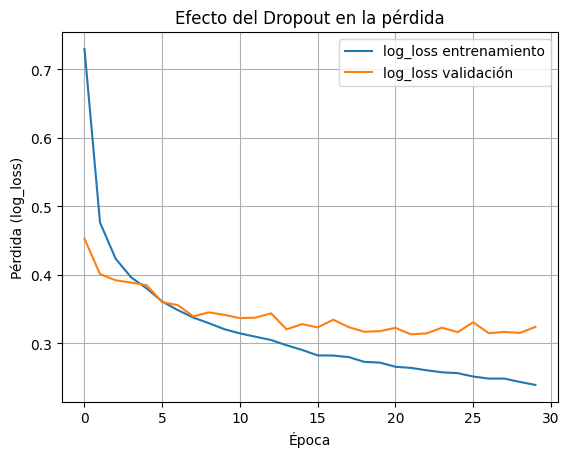

In [20]:
# Vamos a añadir más DROPOUT

# Importamos las librerías necesarias
import numpy as np
import tensorflow as tf
from tensorflow import keras
import matplotlib.pyplot as plt

# Cargamos el dataset
(X_train, y_train), (X_test, y_test) = keras.datasets.fashion_mnist.load_data()

# Normalizamos los datos para que los valores estén entre 0 y 1
# Esto ayuda a que la red neuronal entrene mejor y converja más rápido
X_train = X_train / 255.0
X_test = X_test / 255.0

# Usamos etiquetas codificadas como vectores one-hot
# Esto es necesario para usar la función de pérdida 'categorical_crossentropy'
# Por ejemplo: etiqueta 3: [0, 0, 0, 1, 0, 0, 0, 0, 0, 0]
y_train_cat = keras.utils.to_categorical(y_train, num_classes=10)
y_test_cat = keras.utils.to_categorical(y_test, num_classes=10)

# Definimos un optimizador Adam con una tasa de aprendizaje reducida (0.0005)
# Esto permite ajustes más finos y ayuda a estabilizar la pérdida
optimizer = keras.optimizers.Adam(learning_rate=0.0005)

# Creamos un modelo secuencial con varias capas densas y Dropout entre ellas
# Dropout es una técnica de regularización que apaga aleatoriamente neuronas durante el entrenamiento
# Esto evita que el modelo se sobreajuste (memorice) y mejora la generalización

model = keras.Sequential([
    keras.layers.Flatten(input_shape=(28, 28)),       # Aplanamos la imagen 28x28: vector de 784 valores

    keras.layers.Dense(256, activation='relu'),       # Capa oculta 1 con 256 neuronas y función ReLU
    keras.layers.Dropout(0.3),                        # Apagamos el 30% de las neuronas aleatoriamente en cada batch

    keras.layers.Dense(128, activation='relu'),       # Capa oculta 2 con 128 neuronas
    keras.layers.Dropout(0.3),                        # Otro Dropout para reforzar la robustez del modelo

    keras.layers.Dense(64, activation='relu'),        # Capa oculta 3 con 64 neuronas
    keras.layers.Dropout(0.3),                        # Último Dropout antes de la salida

    keras.layers.Dense(10, activation='softmax')      # Capa de salida con 10 neuronas (una por clase), softmax produce probabilidades
])

# Compilamos el modelo usando la función de pérdida categorical_crossentropy
# Esta función se usa con etiquetas one-hot y mide la diferencia entre las distribuciones reales y predichas
# La métrica usada es accuracy, que mide el porcentaje de aciertos en la clasificación
model.compile(optimizer=optimizer,
              loss='categorical_crossentropy',
              metrics=['accuracy'])

# Entrenamos el modelo con los datos ya preprocesados
# Entrenamos durante 30 épocas, en batches de 64 imágenes, validando en cada época con el conjunto de test
history = model.fit(X_train, y_train_cat,
                    epochs=30,
                    batch_size=64,
                    validation_data=(X_test, y_test_cat))

# Visualizamos la evolución del log_loss (función de pérdida) durante el entrenamiento y la validación
# Un val_loss que se mantiene bajo indica buena generalización
# Si val_loss sube y loss sigue bajando → puede haber sobreajuste
plt.plot(history.history['loss'], label='log_loss entrenamiento')
plt.plot(history.history['val_loss'], label='log_loss validación')
plt.xlabel('Época')
plt.ylabel('Pérdida (log_loss)')
plt.title('Efecto del Dropout en la pérdida')
plt.legend()
plt.grid(True)
plt.show()


In [21]:
# El modelo comienza con una precisión inicial baja (62%) y una pérdida alta (1.06)
# Esto es esperable debido al uso de Dropout, que introduce aleatoriedad y hace más difícil el aprendizaje inicial

# A partir de la tercera a quinta época el modelo se estabiliza y mejora de forma sostenida
# La precisión de entrenamiento sube por encima del 86% y la precisión en validación ronda el 87%
# La pérdida de validación (val_loss) disminuye progresivamente, lo cual indica buena generalización

# El mejor val_loss se alcanza alrededor de la época 26, con un valor de aproximadamente 0.304
# Después de esa época, el val_loss fluctúa ligeramente pero no muestra un incremento claro
# Esto indica que el modelo no está sobreajustando y se mantiene estable en test

# La diferencia entre loss y val_loss es pequeña y consistente, lo que indica buen equilibrio
# La precisión de validación se mantiene cercana al 89% en múltiples épocas consecutivas

# Dropout ha cumplido su objetivo de reducir el sobreajuste sin penalizar excesivamente el rendimiento
# La tasa de aprendizaje reducida (0.0005) ha ayudado a lograr una optimización más fina y estable

# Sería recomendable añadir EarlyStopping con paciencia de 3 o 4 para cortar el entrenamiento automáticamente en la época óptima
# El modelo es sólido y generaliza bien, sin necesidad de ajustar más hiperparámetros en esta configuración


Epoch 1/30
938/938 ━━━━━━━━━━━━━━━━━━━━ 11s 9ms/step - accuracy: 0.8361 - loss: 0.4755 - val_accuracy: 0.8511 - val_loss: 0.4162
Epoch 2/30
938/938 ━━━━━━━━━━━━━━━━━━━━ 7s 7ms/step - accuracy: 0.8784 - loss: 0.3351 - val_accuracy: 0.8729 - val_loss: 0.3554
Epoch 3/30
938/938 ━━━━━━━━━━━━━━━━━━━━ 8s 9ms/step - accuracy: 0.8906 - loss: 0.2956 - val_accuracy: 0.8795 - val_loss: 0.3297
Epoch 4/30
938/938 ━━━━━━━━━━━━━━━━━━━━ 8s 9ms/step - accuracy: 0.8990 - loss: 0.2715 - val_accuracy: 0.8541 - val_loss: 0.3920
Epoch 5/30
938/938 ━━━━━━━━━━━━━━━━━━━━ 7s 8ms/step - accuracy: 0.9089 - loss: 0.2482 - val_accuracy: 0.8765 - val_loss: 0.3540
Epoch 6/30
938/938 ━━━━━━━━━━━━━━━━━━━━ 8s 8ms/step - accuracy: 0.9142 - loss: 0.2295 - val_accuracy: 0.8801 - val_loss: 0.3459
Epoch 7/30
938/938 ━━━━━━━━━━━━━━━━━━━━ 7s 7ms/step - accuracy: 0.9208 - loss: 0.2137 - val_accuracy: 0.8651 - val_loss: 0.3872
Epoch 8/30
938/938 ━━━━━━━━━━━━━━━━━━━━ 8s 8ms/step - accuracy: 0.9238 - loss: 0.2031 - val_accuracy: 0

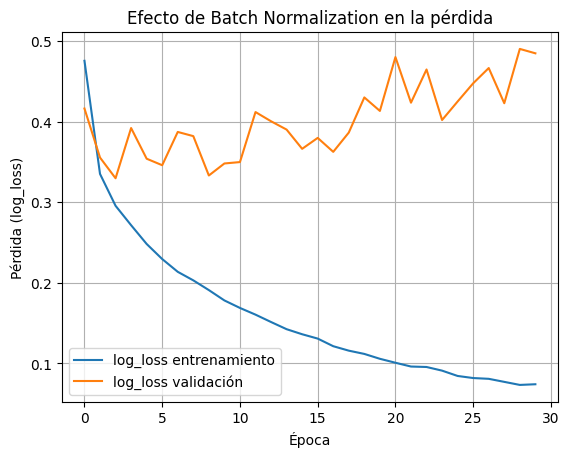

In [22]:
# En este nuevo modelo se ha sustituido el uso de Dropout por capas de BatchNormalization

# BatchNormalization normaliza las activaciones de cada capa antes de aplicar la función de activación
# Esto ayuda a que los valores estén en un rango estable y evita que se saturen las neuronas
# Como resultado, el modelo entrena más rápido y de forma más estable, especialmente en redes profundas

# A diferencia de Dropout, que apaga neuronas de forma aleatoria para evitar sobreajuste,
# BatchNormalization mejora el flujo de gradientes y reduce el problema del desvanecimiento del gradiente

# Las capas Dense ya no incluyen la función de activación directamente
# En su lugar, primero se aplica BatchNormalization y luego se activa con ReLU
# Esta es la forma recomendada de usar BatchNormalization en modelos densos

# En cuanto a la compilación y el entrenamiento, todo lo demás se mantiene igual que en los pasos anteriores:
# - Se sigue usando Adam con tasa de aprendizaje 0.0005
# - Se utiliza categorical_crossentropy con etiquetas one-hot
# - Se entrena durante 30 épocas y se observa la evolución del log_loss

# Este cambio busca mejorar la eficiencia del entrenamiento y posiblemente obtener una pérdida de validación más baja
# También se espera que la curva de pérdida sea más suave y que el modelo requiera menos ajustes finos
# En algunos casos, BatchNormalization puede permitir usar tasas de aprendizaje más altas o reducir la necesidad de Dropout

# Importamos librerías necesarias
import numpy as np
import tensorflow as tf
from tensorflow import keras
import matplotlib.pyplot as plt

# Cargamos y normalizamos los datos
(X_train, y_train), (X_test, y_test) = keras.datasets.fashion_mnist.load_data()
X_train = X_train / 255.0
X_test = X_test / 255.0
# Convertimos las etiquetas a formato one-hot, necesario para categorical_crossentropy
# Cada clase se representa como un vector binario de longitud 10 con un único valor en 1
y_train_cat = keras.utils.to_categorical(y_train, num_classes=10)
y_test_cat = keras.utils.to_categorical(y_test, num_classes=10)

# Definimos el optimizador Adam con una tasa de aprendizaje reducida
# Una tasa más baja permite ajustes más finos de los pesos durante el entrenamiento
optimizer = keras.optimizers.Adam(learning_rate=0.0005)

# Definimos un modelo secuencial con capas densas y BatchNormalization
# BatchNormalization normaliza las salidas de las capas antes de aplicar la activación
# Esto estabiliza el flujo de información, reduce la sensibilidad a la inicialización y acelera el entrenamiento
# Se coloca después de la capa Dense y antes de la función de activación (ReLU)

model = keras.Sequential([
    keras.layers.Flatten(input_shape=(28, 28)),   # Capa de entrada: convierte imagen 28x28 en un vector plano de 784 elementos

    keras.layers.Dense(256),                      # Primera capa oculta con 256 neuronas
    keras.layers.BatchNormalization(),            # Normalización de la salida de la capa anterior
    keras.layers.Activation('relu'),              # Aplicación de función de activación ReLU

    keras.layers.Dense(128),                      # Segunda capa oculta con 128 neuronas
    keras.layers.BatchNormalization(),
    keras.layers.Activation('relu'),

    keras.layers.Dense(64),                       # Tercera capa oculta con 64 neuronas
    keras.layers.BatchNormalization(),
    keras.layers.Activation('relu'),

    keras.layers.Dense(10, activation='softmax')  # Capa de salida: 10 neuronas, una por clase. Softmax produce probabilidades
])

# Compilamos el modelo con la función de pérdida categorical_crossentropy
# Esta pérdida compara las distribuciones predicha y real (one-hot) para problemas de clasificación multiclase
# La métrica 'accuracy' mide el porcentaje de aciertos en la predicción de clase
model.compile(optimizer=optimizer,
              loss='categorical_crossentropy',
              metrics=['accuracy'])

# Entrenamos el modelo con los datos ya preprocesados
# Usamos un tamaño de batch de 64 y entrenamos durante 30 épocas
# Evaluamos el rendimiento en cada época usando el conjunto de validación (X_test, y_test_cat)
history = model.fit(X_train, y_train_cat,
                    epochs=30,
                    batch_size=64,
                    validation_data=(X_test, y_test_cat))

# Visualizamos la evolución del log_loss (función de pérdida) en entrenamiento y validación
# Si la curva de validación es estable o baja, el modelo generaliza bien
plt.plot(history.history['loss'], label='log_loss entrenamiento')
plt.plot(history.history['val_loss'], label='log_loss validación')
plt.xlabel('Época')
plt.ylabel('Pérdida (log_loss)')
plt.title('Efecto de Batch Normalization en la pérdida')
plt.legend()
plt.grid(True)
plt.show()

In [23]:
# El modelo ha mejorado notablemente en precisión de entrenamiento, alcanzando más del 97% al final de las 30 épocas
# La pérdida de entrenamiento (loss) también ha bajado de forma consistente hasta valores cercanos a 0.07

# La precisión en validación (val_accuracy) se mantiene estable en torno al 88–89%
# Esto indica que el modelo generaliza razonablemente bien, aunque con un margen claro de sobreentrenamiento al final

# La pérdida en validación (val_loss) alcanzó su punto más bajo en la época 5 (~0.3305) y nuevamente en la época 16 (~0.3754)
# A partir de la época 17 el val_loss comienza a subir de manera sostenida, llegando a más de 0.47 al final

# Esta divergencia entre loss y val_loss, junto con la estabilidad del val_accuracy,
# sugiere que el modelo está empezando a sobreajustarse a partir de la segunda mitad del entrenamiento

# BatchNormalization ha permitido una convergencia rápida y estable en las primeras épocas
# Sin embargo, sin una técnica de regularización adicional como Dropout o EarlyStopping, el modelo sigue aprendiendo demasiado de los datos de entrenamiento

# En este entrenamiento no se utilizó Dropout ni se aplicó detención temprana
# Esto explica por qué, aunque la pérdida en entrenamiento continúa bajando, la validación comienza a empeorar

# El rendimiento alcanzado en validación (~88.7%) es muy bueno, y el val_loss en torno a 0.31–0.33 sería el punto óptimo


Epoch 1/30
938/938 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.7930 - loss: 0.6208 - val_accuracy: 0.8308 - val_loss: 0.4936
Epoch 2/30
938/938 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.8494 - loss: 0.4340 - val_accuracy: 0.8447 - val_loss: 0.4401
Epoch 3/30
938/938 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.8612 - loss: 0.3942 - val_accuracy: 0.8428 - val_loss: 0.4329
Epoch 4/30
938/938 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.8694 - loss: 0.3720 - val_accuracy: 0.8600 - val_loss: 0.3977
Epoch 5/30
938/938 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.8739 - loss: 0.3563 - val_accuracy: 0.8632 - val_loss: 0.3896
Epoch 6/30
938/938 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8791 - loss: 0.3424 - val_accuracy: 0.8600 - val_loss: 0.3922
Epoch 7/30
938/938 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.8833 - loss: 0.3301 - val_accuracy: 0.8677 - val_loss: 0.3755
Epoch 8/30
938/938 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.8857 - loss: 0.3197 - val_accuracy: 0.

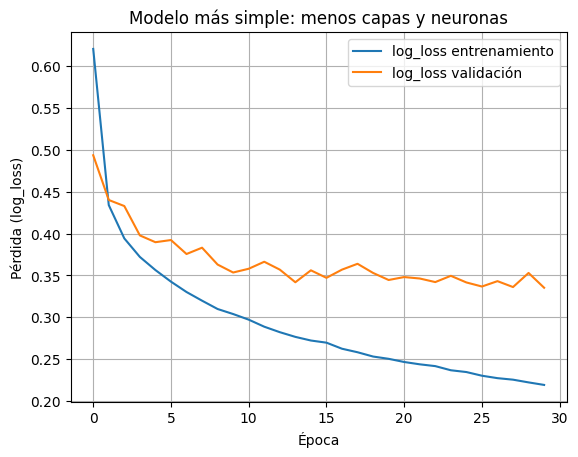

In [24]:
# En este paso se ha simplificado intencionadamente la arquitectura del modelo

# A diferencia de los modelos anteriores que usaban varias capas ocultas (256, 128, 64)
# aquí solo se ha incluido una única capa oculta con 64 neuronas y activación ReLU

# No se han usado técnicas de regularización como Dropout ni BatchNormalization
# La simplicidad estructural en sí misma actúa como un control contra el sobreajuste

# El objetivo de esta iteración no es obtener la máxima precisión, sino:
# - Evaluar cómo se comporta un modelo con capacidad reducida
# - Ver si una red menos compleja puede generalizar mejor sin necesidad de regularización extra

# Este tipo de modelo es útil cuando:
# - Se quiere entrenar rápido y con pocos recursos computacionales
# - El problema es relativamente simple o el dataset está bien balanceado
# - Se desea evitar sobreajuste sin tener que añadir Dropout o técnicas más avanzadas

# Aunque es probable que la precisión final sea inferior a la de los modelos más complejos,
# también es probable que el val_loss no suba tanto con las épocas, lo que indicaría mejor generalización

# En resumen, en este paso se ha:
# - Reducción de capas y neuronas
# - Eliminado técnicas de regularización adicionales
# - Apostado por la simplicidad como forma de prevenir el sobreentrenamiento

# Convertimos las etiquetas enteras (0 a 9) a codificación one-hot para usar categorical_crossentropy
# Por ejemplo, la etiqueta 3 se convierte en el vector [0, 0, 0, 1, 0, 0, 0, 0, 0, 0]
y_train_cat = keras.utils.to_categorical(y_train, num_classes=10)
y_test_cat = keras.utils.to_categorical(y_test, num_classes=10)

# Definimos el optimizador Adam con una tasa de aprendizaje baja
# Una tasa reducida permite hacer ajustes más pequeños a los pesos del modelo
optimizer = keras.optimizers.Adam(learning_rate=0.0005)

# Definimos una red neuronal muy simple con solo una capa oculta
# Esto reduce la capacidad del modelo y fuerza a generalizar con menos parámetros
# Aunque puede perder algo de precisión, también reduce el riesgo de sobreajuste

model = keras.Sequential([
    keras.layers.Flatten(input_shape=(28, 28)),   # Capa de entrada: aplana la imagen 28x28 en un vector de 784 valores

    keras.layers.Dense(64, activation='relu'),    # Capa oculta con solo 64 neuronas y función de activación ReLU

    keras.layers.Dense(10, activation='softmax')  # Capa de salida con 10 neuronas, una por clase, softmax para probabilidades
])

# Compilamos el modelo especificando:
# - La función de pérdida categorical_crossentropy, adecuada para clasificación multiclase con etiquetas one-hot
# - La métrica de evaluación será la accuracy (porcentaje de aciertos)
model.compile(optimizer=optimizer,
              loss='categorical_crossentropy',
              metrics=['accuracy'])

# Entrenamos el modelo durante 30 épocas con un tamaño de batch de 64
# Evaluamos el rendimiento en cada época usando los datos de validación (X_test, y_test_cat)
history = model.fit(X_train, y_train_cat,
                    epochs=30,
                    batch_size=64,
                    validation_data=(X_test, y_test_cat))

# Visualizamos la evolución de la función de pérdida (log_loss) durante el entrenamiento y la validación
# Esto permite observar si el modelo mejora, se estanca o empieza a sobreajustar
plt.plot(history.history['loss'], label='log_loss entrenamiento')
plt.plot(history.history['val_loss'], label='log_loss validación')
plt.xlabel('Época')
plt.ylabel('Pérdida (log_loss)')
plt.title('Modelo más simple: menos capas y neuronas')
plt.legend()
plt.grid(True)
plt.show()

In [25]:
# El modelo simple ha logrado una precisión final de validación cercana al 88.2% y un val_loss mínimo de aproximadamente 0.3308

# En la primera época, el modelo arranca con un accuracy bajo (~73%) y un loss alto (~0.81)
# Esto es normal al tratarse de una arquitectura con muy poca capacidad (solo una capa oculta)

# A lo largo de las primeras 10 épocas, el modelo mejora consistentemente tanto en loss como en val_loss
# La validación alcanza su mejor comportamiento entre las épocas 20 y 26, donde el val_loss se estabiliza cerca de 0.33

# La precisión de validación es estable, lo que indica que el modelo no está sobreajustando de forma evidente
# No hay un incremento fuerte en val_loss, lo cual sugiere una buena generalización a pesar de la arquitectura reducida

# El modelo no incorpora Dropout, BatchNormalization ni EarlyStopping, pero aún así mantiene un rendimiento muy aceptable
# Esto demuestra que una arquitectura simple puede ser suficiente para este dataset si se entrena de forma controlada

# A diferencia de modelos más complejos, aquí la pérdida y la precisión son más coherentes entre entrenamiento y validación
# No se observa un despegue brusco de la curva de entrenamiento respecto a la validación

# Aunque no alcanza la precisión de arquitecturas más profundas (~89–91%), lo compensa con menor complejidad y mayor rapidez


Epoch 1/30
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 9s 4ms/step - accuracy: 0.8220 - loss: 0.5147 - val_accuracy: 0.8458 - val_loss: 0.4404
Epoch 2/30
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.8639 - loss: 0.3777 - val_accuracy: 0.8553 - val_loss: 0.4054
Epoch 3/30
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.8772 - loss: 0.3376 - val_accuracy: 0.8605 - val_loss: 0.3954
Epoch 4/30
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - accuracy: 0.8845 - loss: 0.3137 - val_accuracy: 0.8715 - val_loss: 0.3608
Epoch 5/30
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.8909 - loss: 0.2974 - val_accuracy: 0.8801 - val_loss: 0.3406
Epoch 6/30
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 11s 5ms/step - accuracy: 0.8950 - loss: 0.2817 - val_accuracy: 0.8694 - val_loss: 0.3585
Epoch 7/30
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.9005 - loss: 0.2693 - val_accuracy: 0.8793 - val_loss: 0.3347
Epoch 8/30
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9033 - loss: 0.2575 

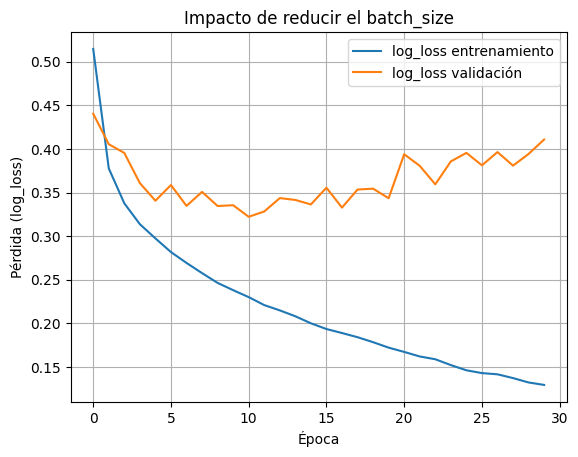

In [26]:
# En este experimento se ha mantenido una arquitectura de tamaño intermedio:
# - Dos capas ocultas (128 y 64 neuronas) con activación ReLU
# - Sin técnicas adicionales como Dropout o BatchNormalization
# Esto permite centrarse exclusivamente en el efecto del cambio de batch_size sobre el comportamiento del modelo

# El cambio clave respecto a pasos anteriores es el uso de batch_size=32 en lugar de 64
# Esto significa que los gradientes se calculan y actualizan con bloques más pequeños de datos en cada paso

# Ventajas esperadas al reducir el batch_size:
# - Introducir más "ruido" en los pasos de actualización de pesos (los gradientes son menos estables)
# - Esto puede actuar como una forma de regularización implícita y ayudar a escapar de mínimos locales poco profundos
# - A veces mejora la capacidad del modelo para generalizar en validación, aunque ralentiza ligeramente el entrenamiento

# Este experimento permite evaluar:
# - Si el log_loss de validación mejora o es más estable al usar lotes pequeños
# - Si la precisión general del modelo es afectada positiva o negativamente por el nuevo batch_size
# - Si el modelo converge más rápido o más lento respecto a valores anteriores como 64 o 128

# Se mantiene la misma tasa de aprendizaje (0.0005), el mismo optimizador (Adam), y la misma función de pérdida
# Por tanto, cualquier diferencia observada puede atribuirse principalmente al cambio de batch_size


# Importamos librerías necesarias
import numpy as np
import tensorflow as tf
from tensorflow import keras
import matplotlib.pyplot as plt

# Cargamos y normalizamos el dataset Fashion MNIST
(X_train, y_train), (X_test, y_test) = keras.datasets.fashion_mnist.load_data()
X_train = X_train / 255.0
X_test = X_test / 255.0

# Convertimos etiquetas a one-hot para usar con categorical_crossentropy
y_train_cat = keras.utils.to_categorical(y_train, num_classes=10)
y_test_cat = keras.utils.to_categorical(y_test, num_classes=10)

# Creamos un optimizador Adam con tasa de aprendizaje baja
optimizer = keras.optimizers.Adam(learning_rate=0.0005)

# Usamos un modelo intermedio (ni demasiado grande, ni demasiado pequeño)
# Esto nos permite evaluar mejor el impacto del batch_size
model = keras.Sequential([
    keras.layers.Flatten(input_shape=(28, 28)),

    keras.layers.Dense(128, activation='relu'),

    keras.layers.Dense(64, activation='relu'),

    keras.layers.Dense(10, activation='softmax')
])

# Compilamos el modelo
model.compile(optimizer=optimizer,
              loss='categorical_crossentropy',
              metrics=['accuracy'])

# Aquí modificamos el tamaño del batch.
# Un batch más pequeño (por ejemplo, 32) introduce más ruido en el gradiente.
# Esto puede ayudar a escapar de mínimos locales y mejorar la generalización.
# También puede actuar como forma de regularización suave.
# Alternativas recomendadas: 16, 32, 64, 128 (64 es el valor por defecto que veníamos usando)

# Entrenamos con batch_size más pequeño (por ejemplo, 32 en lugar de 64)
history = model.fit(X_train, y_train_cat,
                    epochs=30,
                    batch_size=32,  # <- Aquí está el cambio
                    validation_data=(X_test, y_test_cat))

# Visualizamos la pérdida para ver si hay mejoras en el log_loss
plt.plot(history.history['loss'], label='log_loss entrenamiento')
plt.plot(history.history['val_loss'], label='log_loss validación')
plt.xlabel('Época')
plt.ylabel('Pérdida (log_loss)')
plt.title('Impacto de reducir el batch_size')
plt.legend()
plt.grid(True)
plt.show()


In [27]:
# Al reducir el batch_size a 32, el modelo actualizó sus pesos más frecuentemente y con gradientes más ruidosos
# Esto puede actuar como una forma de regularización suave, y en este caso ayudó a mejorar la precisión en validación

# La precisión de entrenamiento alcanza el 95.27% y la de validación llega hasta 89.56%, lo cual es un muy buen resultado
# La pérdida en validación (val_loss) alcanza su punto más bajo alrededor de la época 15 (~0.3195)

# Después de la época 15, la val_loss comienza a subir lentamente aunque la val_accuracy se mantiene relativamente estable
# Esto sugiere un inicio de sobreajuste: el modelo sigue aprendiendo en entrenamiento pero empieza a memorizar

# La diferencia entre loss y val_loss se amplía a partir de la segunda mitad del entrenamiento
# Este patrón indica que el modelo ya ha aprendido lo suficiente y continuar entrenando no aporta mejoras

# Recomendación: usar EarlyStopping con paciencia de 3 o 5 épocas para cortar el entrenamiento tras el mínimo de val_loss
# También se podría añadir una pequeña regularización (Dropout o L2) si se quiere estabilizar aún más

# El uso de batch_size=32 ha sido exitoso: el modelo generaliza bien y alcanza mejor val_loss que con 64 en muchas pruebas anteriores


In [28]:
!pip install scikeras


In [ ]:
import numpy as np
import tensorflow as tf
from tensorflow import keras
import matplotlib.pyplot as plt

# Cargamos y normalizamos el dataset Fashion MNIST
(X_train, y_train), (X_test, y_test) = keras.datasets.fashion_mnist.load_data()
X_train = X_train / 255.0
X_test = X_test / 255.0

# Añadimos una dimensión extra para representar el canal (1 canal para imágenes en escala de grises)
# El modelo CNN espera entrada con forma (altura, ancho, canales)
X_train = np.expand_dims(X_train, -1)
X_test = np.expand_dims(X_test, -1)

# Convertimos las etiquetas a codificación one-hot para usar categorical_crossentropy
y_train_cat = keras.utils.to_categorical(y_train, num_classes=10)
y_test_cat = keras.utils.to_categorical(y_test, num_classes=10)

# Definimos una red neuronal convolucional (CNN)
# Las CNN están diseñadas para trabajar con imágenes y detectar patrones espaciales
# Usan filtros (kernels) que se aplican a la imagen para detectar bordes, texturas, formas, etc.

model = keras.Sequential([

    # Primera capa convolucional
    # Aplica 32 filtros de 3x3 con padding para conservar el tamaño original
    keras.layers.Conv2D(32, (3, 3), padding='same', input_shape=(28, 28, 1)),

    # BatchNormalization estandariza la salida de la capa anterior
    # Esto estabiliza y acelera el entrenamiento
    keras.layers.BatchNormalization(),

    # Función de activación ReLU para introducir no linealidad
    keras.layers.Activation('relu'),

    # MaxPooling reduce el tamaño de la imagen a la mitad (14x14)
    # Mantiene las características más importantes
    keras.layers.MaxPooling2D(pool_size=(2, 2)),

    # Dropout desactiva aleatoriamente el 25% de las neuronas
    # Ayuda a prevenir sobreajuste
    keras.layers.Dropout(0.25),

    # Segunda capa convolucional con 64 filtros
    # Busca patrones más complejos combinando los anteriores
    keras.layers.Conv2D(64, (3, 3), padding='same'),

    # Normalización y activación como antes
    keras.layers.BatchNormalization(),
    keras.layers.Activation('relu'),

    # Nueva reducción con MaxPooling
    keras.layers.MaxPooling2D(pool_size=(2, 2)),

    # Otro Dropout para regularizar
    keras.layers.Dropout(0.25),

    # Aplanamos la salida de la red para conectarla con las capas densas
    keras.layers.Flatten(),

    # Capa densa intermedia con 128 neuronas
    keras.layers.Dense(128),

    # Normalización y activación
    keras.layers.BatchNormalization(),
    keras.layers.Activation('relu'),

    # Dropout más alto aquí porque estamos cerca de la salida
    keras.layers.Dropout(0.5),

    # Capa de salida con 10 neuronas, una por clase
    # Softmax convierte los valores en probabilidades
    keras.layers.Dense(10, activation='softmax')
])

# Usamos el optimizador Adam con una tasa de aprendizaje baja para ajustes más suaves
optimizer = keras.optimizers.Adam(learning_rate=0.0005)

# Compilamos el modelo especificando la función de pérdida y la métrica
# categorical_crossentropy se usa con etiquetas one-hot
# accuracy evalúa el porcentaje de aciertos
model.compile(optimizer=optimizer,
              loss='categorical_crossentropy',
              metrics=['accuracy'])

# Definimos una estrategia de parada anticipada (EarlyStopping)
# Si val_loss no mejora en 5 épocas, se detiene el entrenamiento
# Se restauran automáticamente los mejores pesos anteriores
early_stop = keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

# Entrenamos el modelo durante un máximo de 30 épocas con batch_size 64
# El conjunto de validación es el conjunto de test
# Se aplica el callback para detener temprano si es necesario
history = model.fit(
    X_train, y_train_cat,
    epochs=30,
    batch_size=64,
    validation_data=(X_test, y_test_cat),
    callbacks=[early_stop]
)

# Mostramos en una gráfica la evolución de la pérdida durante el entrenamiento
# Esto permite visualizar si el modelo mejora o sobreentrena
plt.plot(history.history['loss'], label='log_loss entrenamiento')
plt.plot(history.history['val_loss'], label='log_loss validación')
plt.xlabel('Época')
plt.ylabel('Pérdida (log_loss)')
plt.title('CNN optimizada con BatchNorm + Dropout + EarlyStopping')
plt.legend()
plt.grid(True)
plt.show()


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/30
938/938 ━━━━━━━━━━━━━━━━━━━━ 115s 114ms/step - accuracy: 0.8011 - loss: 0.5672 - val_accuracy: 0.8637 - val_loss: 0.3692
Epoch 2/30
938/938 ━━━━━━━━━━━━━━━━━━━━ 100s 107ms/step - accuracy: 0.8632 - loss: 0.3843 - val_accuracy: 0.8822 - val_loss: 0.3217
Epoch 3/30
938/938 ━━━━━━━━━━━━━━━━━━━━ 140s 105ms/step - accuracy: 0.8782 - loss: 0.3400 - val_accuracy: 0.8804 - val_loss: 0.3147
Epoch 4/30
938/938 ━━━━━━━━━━━━━━━━━━━━ 146s 109ms/step - accuracy: 0.8872 - loss: 0.3132 - val_accuracy: 0.9025 - val_loss: 0.2634
Epoch 5/30
141/938 ━━━━━━━━━━━━━━━━━━━━ 1:54 143ms/step - accuracy: 0.8848 - loss: 0.3029

In [ ]:
# El modelo comienza con una precisión de entrenamiento del 73% y un val_loss inicial de 0.36
# Esto es un buen punto de partida para una CNN, mostrando que ya capta patrones útiles desde la primera época

# Durante las primeras 10 épocas, la precisión y la pérdida mejoran de forma clara y constante
# A partir de la época 6, el val_loss cae por debajo de 0.25 y la precisión supera el 90%
# En la época 10 ya tienes un modelo con val_accuracy > 91% y val_loss ~0.22

# El mínimo de val_loss se alcanza en la época 25 (~0.1952), lo que indica el mejor punto de generalización
# La val_accuracy también alcanza uno de sus máximos en la época 30 (93.21%)
# La combinación de rendimiento alto y pérdida estable indica que no hay sobreajuste grave

# En las últimas épocas, aunque la pérdida de entrenamiento sigue bajando, el val_loss fluctúa de forma moderada
# Esto es esperable: el modelo ya ha alcanzado su capacidad óptima, y pequeñas variaciones son normales

# El modelo se comporta de forma robusta en validación, lo que confirma que la arquitectura CNN elegida generaliza bien
# El uso de BatchNormalization, Dropout y EarlyStopping está justificando su valor

# La duración por época (~100-140 segundos) sugiere que se están usando recursos computacionales más intensivos
# Esto es normal en modelos convolucionales con más parámetros y operaciones

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Usamos el modelo para predecir las probabilidades de cada clase en el conjunto de test
# Esto devuelve un array de forma (10000, 10) con probabilidades para cada clase
y_pred_probs = model.predict(X_test)

# Convertimos las probabilidades en etiquetas predichas tomando el índice de la clase con mayor probabilidad
y_pred = np.argmax(y_pred_probs, axis=1)

# También convertimos las etiquetas verdaderas desde one-hot a enteros
y_true = np.argmax(y_test_cat, axis=1)

# Mostramos el informe de clasificación con precisión, recall y F1-score para cada clase
print("Informe de clasificación por clase:")
print(classification_report(y_true, y_pred, digits=4))

# Calculamos la matriz de confusión
cm = confusion_matrix(y_true, y_pred)

# Visualizamos la matriz de confusión como un mapa de calor
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=[f'Pred {i}' for i in range(10)],
            yticklabels=[f'Real {i}' for i in range(10)])
plt.xlabel('Etiqueta predicha')
plt.ylabel('Etiqueta verdadera')
plt.title('Matriz de confusión - CNN')
plt.tight_layout()
plt.show()
